In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils import MeltingTemp as mt
from Bio.Seq import Seq
import pandas as pd
from itertools import product
import warnings
warnings.filterwarnings("ignore")

In [9]:
def gen_smart_nicking_lib(seq, left, right):
    # Parameters for sequence design
    tm_left_min = 59
    tm_left_max = 66
    target_tm_right = 61
    min_len_left = 19
    max_len_left = 40
    min_len_right = 18
    max_len_right = 40
    # Calculate the number of codons, excluding the start codon
    codon_num = int(len(seq) / 3)
    # Concatenate the left, sequence, and right to form the full sequence
    full_seq = left + seq + right
    # Initialize variables for storing information
    oligos_dict = {}
    best_left_lens = []
    best_right_lens = []
    best_left_tms = []
    best_right_tms = []
    best_lens = []
    best_tms = []
    SSSs = 0
    SSWs = 0
    SWSs = 0
    weak_clamps = 0
    SW_dict = {'A': 'W', 'T': 'W', 'C': 'S', 'G': 'S'}  # Dictionary for nucleotide clamps
    NNSs = 0
    NNKs = 0
    # Iterate over each codon
    for codon in range(1, codon_num):
        # Define the start and stop positions of the codon
        codon_start = len(left) + codon * 3
        codon_stop = len(left) + (codon * 3) + 3

        # Extract the wild-type codon
        wt_codon = full_seq[codon_start:codon_stop]

        # Find the best left flanking sequence
        temp_dict_left = {}
        temp_winners_list = []
        SW_winners_dict = {'SSS': [], 'SSW': [], 'SWS': []}

        # Generate and store left flanking sequences with their melting temperatures (Tms)
        for i in range(min_len_left, max_len_left + 1):
            left_tm = mt.Tm_NN(Seq(full_seq[codon_start - i:codon_start]))
            temp_dict_left[i] = left_tm
            if tm_left_min <= left_tm <= tm_left_max:
                temp_winners_list.append(i)
                left_clamp = ''.join([SW_dict[nuc] for nuc in full_seq[codon_start - i:codon_start][0:3]])
                if left_clamp in ['SSS', 'SSW', 'SWS']:
                    SW_winners_dict[left_clamp].append(i)

        winner_found = False
        best_len = 0
        best_tm = 0
        double_synth = False

        # Look for a winner with SSS clamp
        for i in temp_winners_list:
            if not winner_found:
                if i in SW_winners_dict['SSS']:
                    best_len = i
                    best_tm = temp_dict_left[i]
                    SSSs += 1
                    winner_found = True

        # If no SSS winner found, look for SSW or SWS winners
        for i in temp_winners_list:
            if not winner_found:
                if i in SW_winners_dict['SSW']:
                    best_len = i
                    best_tm = temp_dict_left[i]
                    SSWs += 1
                    winner_found = True
                elif i in SW_winners_dict['SWS']:
                    best_len = i
                    best_tm = temp_dict_left[i]
                    SWSs += 1
                    winner_found = True

        if winner_found:
            best_left_seq = full_seq[codon_start - best_len:codon_start]
            best_lens.append(best_len)
            best_left_lens.append(best_len)
            best_tms.append(best_tm)
            best_left_tms.append(best_tm)
        else:
            # If no winner found, choose the target_tm_right for left flank
            best_len, best_tm = min(temp_dict_left.items(), key=lambda x: abs(target_tm_right - x[1]))
            best_left_seq = full_seq[codon_start - best_len:codon_start]
            best_tms.append(best_tm)
            best_left_tms.append(best_tm)
            double_synth = True
            weak_clamps += 1

        # Find the best right flanking sequence
        temp_dict_right = {}
        # Generate and store right flanking sequences with their melting temperatures (Tms)
        for i in range(min_len_right, max_len_right + 1):
            temp_dict_right[i] = mt.Tm_NN(Seq(full_seq[codon_stop:codon_stop + i]))

        best_len, best_tm = min(temp_dict_right.items(), key=lambda x: abs(target_tm_right - x[1]))
        best_right_seq = full_seq[codon_stop:codon_stop + best_len]
        best_lens.append(best_len)
        best_right_lens.append(best_len)
        best_tms.append(best_tm)
        best_right_tms.append(best_tm)
        # Determine the degenerate codon based on the last base of the wild-type codon
        if wt_codon[-1] in ['A', 'C', 'G']:
            degen_codon = 'NNK'
            NNKs += 1
        elif wt_codon[-1] in ['T']:
            degen_codon = 'NNS'
            NNSs += 1
        # Generate the final oligo by concatenating the left flanking sequence, degenerate codon, and right flanking sequence
        oligo = best_left_seq + degen_codon + best_right_seq
        oligos_dict[codon + 1] = oligo

        if double_synth:
            oligos_dict[str(codon + 1) + 'R'] = oligo
    # Generate and display violin plots for best Tms and best lengths of left and right flanking sequences
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    sns.set(font_scale = 1.00, font = "arial", rc={'figure.figsize':(6,5)}, style = "ticks")
    sns.violinplot(ax=axes[0], data=[best_left_tms, best_right_tms], palette = "viridis", cut = 1)
    axes[0].set_title('Annealing Temperature')
    axes[0].set_xticklabels(['Left Arm', 'Right Arm'])
    sns.violinplot(ax=axes[1], data=[best_left_lens, best_right_lens], palette = "viridis")
    axes[1].set_title('Primer Length')
    axes[1].set_xticklabels(['Left Arm', 'Right Arm'])
    plt.tight_layout()
    plt.savefig("GBA1.png", dpi = 330)
    # Print statistics
    #divide by codon_num-1, since we aren't mutating the start codon
    print ('total = ', (codon_num-1))
    print ('SSS = ', SSSs,',', SSSs/(codon_num-1))
    print ('SSW = ', SSWs,',', SSWs/(codon_num-1))
    print ('SWS = ', SWSs,',', SWSs/(codon_num-1))
    print ('weak_clamps =', weak_clamps, ',', weak_clamps/(codon_num-1))
    print ('NNKs = ', NNKs)
    print ('NNSs = ', NNSs)
    df = pd.DataFrame.from_dict(oligos_dict, orient='index', columns=['primer'])
    df = df.reset_index().rename(columns = {"index":"position"})
    return df

total =  536
SSS =  330 , 0.6156716417910447
SSW =  83 , 0.15485074626865672
SWS =  119 , 0.22201492537313433
weak_clamps = 4 , 0.007462686567164179
NNKs =  426
NNSs =  110


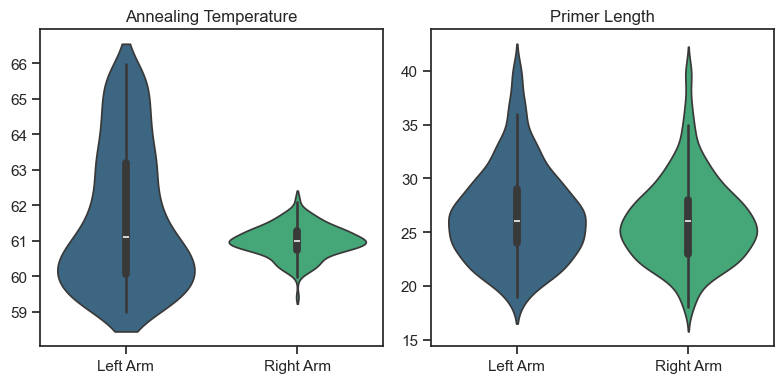

In [10]:
#left_flank and right flank should be the bases before and after the region to be mutagenized. 45nt
left = 'CTTAAGCTTGGTACCGAGCTCGGATCCCCCGGGGAATTCGCCCTT'
right = 'GCGGCCGCTTACCCATACGATGTGAGCTCGCCTAGACCCAGCTTT'
#sequence is coding sequence for the mutagenesis target, including start codon, excluding stop codon.
sequence = 'ATGGAGTTTTCAAGTCCTTCCAGAGAGGAATGTCCCAAGCCTTTGAGTAGGGTAAGCATCATGGCTGGCAGCCTCACAGGATTGCTTCTACTTCAGGCAGTGTCGTGGGCATCAGGTGCCCGCCCCTGCATCCCTAAAAGCTTCGGCTACAGCTCGGTGGTGTGTGTCTGCAATGCCACATACTGTGACTCCTTTGACCCCCCGACCTTTCCTGCCCTTGGTACCTTCAGCCGCTATGAGAGTACACGCAGTGGGCGACGGATGGAGCTGAGTATGGGGCCCATCCAGGCTAATCACACGGGCACAGGCCTGCTACTGACCCTGCAGCCAGAACAGAAGTTCCAGAAAGTGAAGGGATTTGGAGGGGCCATGACAGATGCTGCTGCTCTCAACATCCTTGCCCTGTCACCCCCTGCCCAAAATTTGCTACTTAAATCGTACTTCTCTGAAGAAGGAATCGGATATAACATCATCCGGGTACCCATGGCCAGCTGTGACTTCTCCATCCGCACCTACACCTATGCAGACACCCCTGATGATTTCCAGTTGCACAACTTCAGCCTCCCAGAGGAAGATACCAAGCTCAAGATACCCCTGATTCACCGAGCCCTGCAGTTGGCCCAGCGTCCCGTTTCACTCCTTGCCAGCCCCTGGACATCACCCACTTGGCTCAAGACCAATGGAGCGGTGAATGGGAAGGGGTCACTCAAGGGACAGCCCGGAGACATCTACCACCAGACCTGGGCCAGATACTTTGTGAAGTTCCTGGATGCCTATGCTGAGCACAAGTTACAGTTCTGGGCAGTGACAGCTGAAAATGAGCCTTCTGCTGGGCTGTTGAGTGGATACCCCTTCCAGTGCCTGGGCTTCACCCCTGAACATCAGCGAGACTTCATTGCCCGTGACCTAGGTCCTACCCTCGCCAACAGTACTCACCACAATGTCCGCCTACTCATGCTGGATGACCAACGCTTGCTGCTGCCCCACTGGGCAAAGGTGGTACTGACAGACCCAGAAGCAGCTAAATATGTTCATGGCATTGCTGTACATTGGTACCTGGACTTTCTGGCTCCAGCCAAAGCCACCCTAGGGGAGACACACCGCCTGTTCCCCAACACCATGCTCTTTGCCTCAGAGGCCTGTGTGGGCTCCAAGTTCTGGGAGCAGAGTGTGCGGCTAGGCTCCTGGGATCGAGGGATGCAGTACAGCCACAGCATCATCACGAACCTCCTGTACCATGTGGTCGGCTGGACCGACTGGAACCTTGCCCTGAACCCCGAAGGAGGACCCAATTGGGTGCGTAACTTTGTCGACAGTCCCATCATTGTAGACATCACCAAGGACACGTTTTACAAACAGCCCATGTTCTACCACCTTGGCCACTTCAGCAAGTTCATTCCTGAGGGCTCCCAGAGAGTGGGGCTGGTTGCCAGTCAGAAGAACGACCTGGACGCAGTGGCACTGATGCATCCCGATGGCTCTGCTGTTGTGGTCGTGCTAAACCGCTCCTCTAAGGATGTGCCTCTTACCATCAAGGATCCTGCTGTGGGCTTCCTGGAGACAATCTCACCTGGCTACTCCATTCACACCTACCTGTGGCGTCGCCAGTGA'
#here you can tune parameters.
primers = gen_smart_nicking_lib(sequence, left, right)

In [12]:
seqLen = len(sequence) / 3
chunkCount = 10
chunkLength = round(seqLen / chunkCount)

print (f'each oligo pool is covering {chunkLength} amino acids')
for a in range(chunkCount):
    start_index = chunkLength * a
    end_index = start_index + chunkLength
    
    # Adjust the end index for the last chunk if necessary
    if end_index > len(df):
        end_index = len(df)  # Ensure it doesn't go beyond the data size
    
    selected_interval = df[start_index:end_index]

    print(start_index)
    print(end_index)

    # Check if the current chunk covers beyond the total sequence length
    if a == chunkCount - 1 and end_index < seqLen:
        raise ValueError("Full sequence is not covered.")

    selected_interval["Pool name"] = "pool_" + str(a + 1)
    selected_interval = selected_interval[["Pool name", "Sequence"]]
    
    # Export to Excel
    selected_interval.to_excel("MOLigos_GBA1_SUNi_pool_" + str(a + 1) + ".xlsx", index=False)

print (f'the last pool is covering {int(seqLen-start_index)} amino acids')


each oligo pool is covering 54 amino acids
0
54
54
108
108
162
162
216
216
270
270
324
324
378
378
432
432
486
486
540
the last pool is covering 51 amino acids
